In [55]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [56]:
X,Y=make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=50)

In [57]:
df=pd.DataFrame({'feature':X[:,0],'target':Y})

In [58]:
df.head()

,feature,target
0,-0.389359,-84.227695
1,-0.241215,-44.261245
2,-0.256116,-26.866605
3,0.524342,32.899078
4,-0.679394,-108.732911


Text(0, 0.5, 'target')

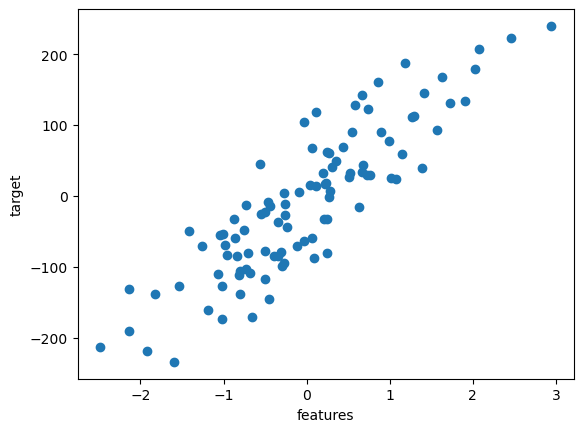

In [59]:
plt.scatter(X,Y)
plt.xlabel("features")
plt.ylabel("target")

In [60]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [61]:
from sklearn.linear_model import Ridge
rig=Ridge(alpha=10)
rig.fit(x_train,y_train)

Ridge(alpha=10)

In [62]:
y_pred=rig.predict(x_test)
y_pred[15]

np.float64(-63.05326969842586)

In [63]:
print('slope',rig.coef_)
print('intercept',rig.intercept_)

slope [79.90861325]
intercept -8.763850232599253


## my ridge regression 

In [64]:
class MRR:
    def __init__(self,alpha=0.1):
        self.m=None
        self.b=None
        self.alpha=alpha

    def fit(self,x_train,y_train):
        #slope term
        num=0
        den=0

        for i in range(x_train.shape[0]):
            num=num+((y_train[i]-y_train.mean())*((x_train[i]-x_train.mean())))
            den=den+((x_train[i]-x_train.mean())*((x_train[i]-x_train.mean())))
        self.m=num/(den+self.alpha)
        #intercept  (b=y^-mx^)
        self.b=y_train.mean()-(self.m*x_train.mean())
        print(self.m)
        print(self.b)

    def predict(self,x_test):
        return self.m*x_test+self.b
    

In [65]:
mrr=MRR(alpha=10)

In [66]:
mrr.fit(x_train,y_train)

[79.90861325]
[-8.76385023]


In [68]:
y_pred=mrr.predict(x_test)
y_pred[15]

array([-63.0532697])

## ridge for nD data 

In [69]:
X,Y=make_regression(n_samples=100,n_features=3,n_informative=3,n_targets=1,noise=50)

In [70]:
df=pd.DataFrame({'feature 1':X[:,0],'feature 2':X[:,1],'feature 3':X[:,2],'target':Y})

In [71]:
df.head()

,feature 1,feature 2,feature 3,target
0,0.199635,0.023670,0.552575,28.341255
1,0.760826,-0.827159,-0.081072,16.650356
2,-0.578831,0.195830,2.726145,95.896686
3,0.302129,-0.901007,0.589232,7.348378
4,0.885553,-0.042209,-2.569044,-128.961687


In [72]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [73]:
rig=Ridge(alpha=10)
rig.fit(x_train,y_train)

Ridge(alpha=10)

In [74]:
y_pred=rig.predict(x_test)
y_pred[11]

np.float64(-162.6390952890832)

In [75]:
print('slope',rig.coef_)
print('intercept',rig.intercept_)

slope [54.54072804 55.86729433 66.51542596]
intercept -2.931061736302209


## my nD ridge

In [86]:
class NRR:
    def __init__(self,alpha=0.1):
        self.coef_=None
        self.intercept_=None
        self.alpha=alpha

    def fit(self,x_train,y_train):
        x_train=np.insert(x_train,0,1,axis=1)
        I=np.identity(x_train.shape[1])

        '''in scikit learn's ridge the 1st row 1st col of identity matris is 0, bcoz in W(weights) matrix the 1st term is intercept 
        and wee have to multiply alpha to slopes only.'''
        I[0][0]=0

        weights=np.linalg.inv(np.dot(x_train.T,x_train)+self.alpha*I).dot(x_train.T).dot(y_train)
        self.intercept_=weights[0]
        self.coef_=weights[1:]

        print(self.intercept_)
        print(self.coef_)
        
    def predict(self,x_test):
        return np.dot(x_test,self.coef_)+self.intercept_
        

In [87]:
nrr=NRR(alpha=10)

In [88]:
nrr.fit(x_train,y_train)


-2.931061736302207
[54.54072804 55.86729433 66.51542596]


In [89]:
y_pred=nrr.predict(x_test)
y_pred[11]

np.float64(-162.63909528908317)